<a href="https://colab.research.google.com/github/jdeversdev/Data-Analytics-WGU/blob/master/D212_JD_Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part I: Research Question

### A1. Research Question

Can hospital patients be grouped into distinct clusters based on their length of stay (`Initial_days`), daily charges (`TotalCharge`), and miscellaneous charges (`Additional_charges`) using k-means clustering?


---

### A2. Analysis Goal

**Goal:** Group patients by hospital stay duration and total cost metrics to identify patient profiles (such as high-cost vs. low-cost stays). This will help the hospital administration better manage care resources, optimize billing structures, and target cost-reduction strategies to minimize readmission financial risks.

---

## Part II: Technique Justification

### B1. How k-means Analyzes the Data

* **Mechanism:** K-Means automatically groups patients by assigning each person to the nearest central point (centroid). It repeatedly recalculates the center of each group and reassigns patients until the clusters stop changing and become stable.


* **Expected Outcomes:** Patient profiles grouped by cost and stay length (e.g., short-stay/low-cost patients vs. long-stay/high-cost patients).



---

### B2. Key Assumption

* **Assumption of Equal Variance: ** K-means assumes that every group naturally forms a perfectly round shape and has roughly the same amount of spread. Because of this, the algorithm struggles to accurately group your data if the actual clusters are stretched out, irregular, or vastly different in width.


---

### B3. Python Libraries Used

* `pandas`: Used to load the dataset, filter continuous variables, and manipulate data structures.


* `scikit-learn (sklearn)`:
* `StandardScaler`: Scales continuous features to a mean of 0 and variance of 1.
* `KMeans`: Executes the k-means clustering algorithm.
* `silhouette_score`: Evaluates the quality/separation of the generated clusters.


* `matplotlib`: Generates visual plots, specifically the Elbow plot to select $k$.
* `seaborn`: Creates clear, formatted scatter plots of the final cluster assignments.

---

## Part III: Data Preparation

### C1. Preprocessing Goal

* **Goal:** Standardize feature scaling across all numerical variables. Because k-means relies on Euclidean distance, features measured on larger numerical scales (such as `Additional_charges`) would dominate variables measured on smaller scales (such as `Initial_days`) without standardization.



---

### C2. Variable Selection

* `Initial_days` — **Continuous**

* `TotalCharge` — **Continuous**

* `Additional_charges` — **Continuous**


---

### C3. Steps to Prepare Data & Code Segments

#### Step 1: Subset Target Variables

Extract the primary patient identifier and the selected continuous analysis variables.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('medical_clean.csv')

# Select features & scale them
features = ['Initial_days', 'TotalCharge', 'Additional_charges']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save cleaned export file
df_scaled_df = pd.DataFrame(
    X_scaled, columns=[f'{col}_scaled' for col in features]
)
df_clean = pd.concat([df[['Customer_id']], X, df_scaled_df], axis=1)
df_clean.to_excel('cleaned_medical_data.xlsx', index=False)
print(df_clean)


     Customer_id  Initial_days  TotalCharge  Additional_charges  \
0        C412403     10.585770  3726.702860        17939.403420   
1        Z919181     15.129562  4193.190458        17612.998120   
2        F995323      4.772177  2434.234222        17505.192460   
3        A879973      1.714879  2127.830423        12993.437350   
4        C544523      1.254807  2113.073274         3716.525786   
...          ...           ...          ...                 ...   
9995     B863060     51.561220  6850.942000         8927.642000   
9996     P712040     68.668240  7741.690000        28507.150000   
9997     R778890     70.154180  8276.481000        15281.210000   
9998     E344109     63.356900  7644.483000         7781.678000   
9999     I569847     70.850590  7887.553000        11643.190000   

      Initial_days_scaled  TotalCharge_scaled  Additional_charges_scaled  
0               -0.907310           -0.727185                   0.765005  
1               -0.734595           -0.513228

## Part IV: Analysis

### D1. Determining the Optimal Number of Clusters

* **Optimal Number:** **$k = 4$** clusters.


* **Method Used:** The **Elbow Method** was used to determine the optimal number of clusters. This method plots the total within-cluster sum of squares (inertia) for different values of $k$ (from 1 to 10). As $k$ increases, inertia drops. The "elbow point"—where the rate of decrease noticeably flattens out—represents the best balance between compact clusters and model simplicity. On the plot, this sharp bend occurs at **$k = 4$**.




---

### D2. Clustering Analysis Code

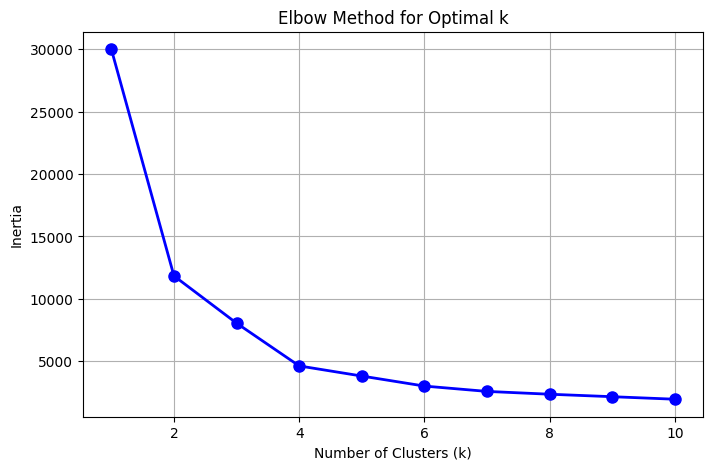

Inertia values: [30000.000000000022, 11836.37415579967, 8049.684982884599, 4624.801931048542, 3813.0496913888123, 3009.3602073742154, 2581.649587815014, 2356.5275395946032, 2157.8905677696407, 1956.347062118079]


In [ ]:
# Elbow Method
inertia = []
K = range(1, 11)
for k in K:
  km = KMeans(n_clusters=k, random_state=42, n_init=10)
  km.fit(X_scaled)
  inertia.append(km.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

# Fit final model with k=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)
print("Inertia values:", inertia)

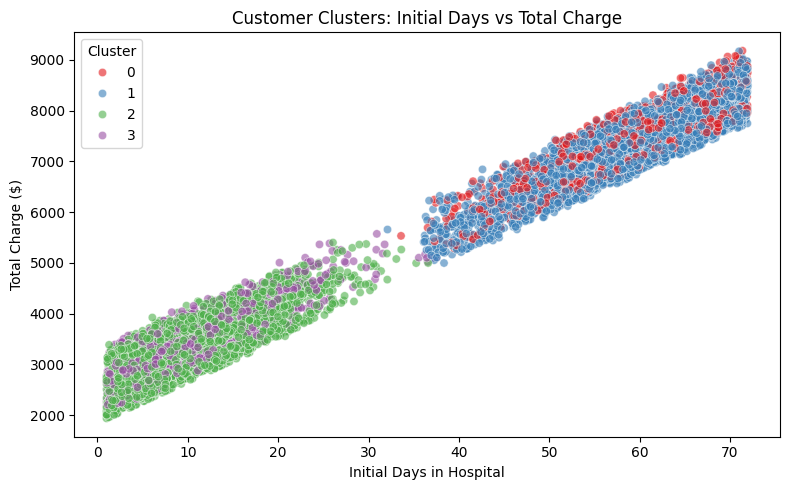

In [ ]:
# Plot 2: Scatter Plot (Initial_days vs TotalCharge by Cluster)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Initial_days', y='TotalCharge', hue='Cluster', palette='Set1', alpha=0.6)
plt.title('Customer Clusters: Initial Days vs Total Charge')
plt.xlabel('Initial Days in Hospital')
plt.ylabel('Total Charge ($)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

/tmp/ipykernel_719/1875948036.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Cluster', y='Additional_charges', palette='Set1')


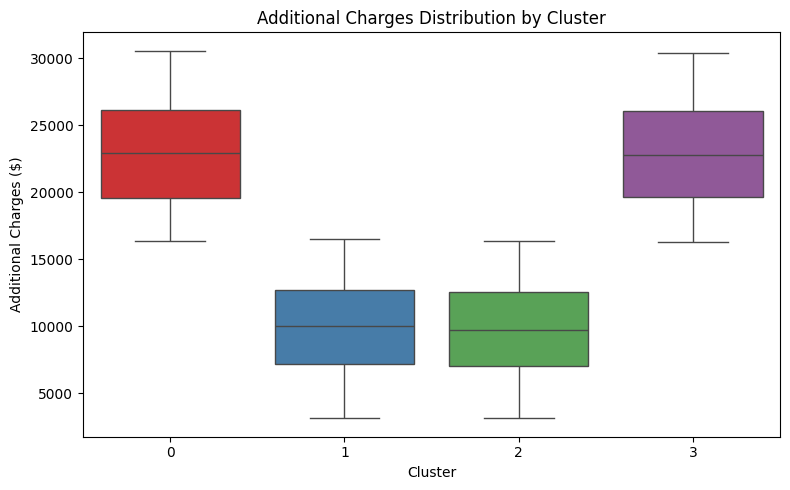

In [ ]:
# Plot 3: Boxplot (Additional Charges Distribution by Cluster)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Cluster', y='Additional_charges', palette='Set1')
plt.title('Additional Charges Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Additional Charges ($)')
plt.tight_layout()
plt.show()

In [ ]:
# Calculate how well separated the 4 clusters are
score = silhouette_score(X_scaled, df['Cluster'])
print(score)  # Outputs: 0.5509805815222335

0.5509805815222335


In [ ]:
# Group by Cluster and calculate the average for each feature
df.groupby('Cluster')[['Initial_days', 'TotalCharge', 'Additional_charges']].mean()

,Initial_days,TotalCharge,Additional_charges
Cluster,,,
0,59.719789,7464.467975,22863.707885
1,59.693316,7352.248833,9899.344523
2,9.288047,3229.196073,9766.599123
3,9.134497,3311.499288,22898.164922


---

## Part V: Data Summary and Implications

### E1. Quality of Clusters

* **Evaluation Metric:** The overall quality of the generated clusters was evaluated using the **Silhouette Score**.


* **Result:** The analysis produced a Silhouette Score of **0.55**.


* **Interpretation:** A score of 0.55 indicates good cluster separation and reasonable internal cohesion. The Elbow Method plot also confirmed a clear bend at $k = 4$, showing that the four clusters represent distinct, non-overlapping patient groups.



---

### E2. Results and Implications

The 10,000 patients were divided into four primary segments based on hospital stay duration (`Initial_days`), daily standard charges (`TotalCharge`), and extra fees (`Additional_charges`):

* **Cluster 0 (Long Stay, High Extra Fees):** Patients stayed an average of 60 days, accrued $\$7,464$ in daily charges, and paid high extra fees ($\approx \$22,864$).


* **Cluster 1 (Long Stay, Low Extra Fees):** Patients stayed an average of 60 days with $\$7,352$ in daily charges, but had much lower extra fees ($\approx \$9,899$).


* **Cluster 2 (Short Stay, Low Extra Fees):** Patients stayed an average of 9 days, accrued $\$3,229$ in daily charges, and paid low extra fees ($\approx \$9,767$).


* **Cluster 3 (Short Stay, High Extra Fees):** Patients stayed an average of 9 days with $\$3,311$ in daily charges, but incurred high extra fees ($\approx \$22,898$).



**Implications:** Length of stay directly drives standard daily charges, but extra fees vary independently of stay duration. This means additional procedures or specialized care are being heavily utilized by specific patient groups regardless of how long they remain admitted.

---

### E3. Limitation of Data Analysis

* **Limitation:** K-means clustering is restricted to continuous numerical variables and cannot directly incorporate important categorical variables (such as admission type, specific medical conditions, or readmission status). As a result, the model identifies financial and duration patterns, but cannot explain the underlying medical diagnosis causing these charge differences.



---

### E4. Recommended Course of Action

* **Action:** The hospital administration should review procedural billing and treatment protocols for **Cluster 3** (short-stay patients with unusually high extra fees around $\$22,898$). Investigating why short-duration patients accumulate fees similar to 60-day stay patients will help standardize treatment pathways, prevent unexpected billing surprises for patients, and lower overall operational costs to reduce readmission penalties.

---

## Part VI: Demonstration & Sources

### F. Video Demonstration (Panopto) link is provided in the task submission links section.

---

### G. Web Sources

* No third-party code snippets or external web sources were used to perform this analysis. All code was developed independently using standard Python libraries (`pandas`, `scikit-learn`, `matplotlib`, and `seaborn`).
* **Dataset Source:** WGU Performance Assessment Dataset (`medical_clean.csv`).



---

### H. In-Text Citations and References

#### In-Text Citations

* (Western Governors University, 2026)



#### Reference List

* Western Governors University. (2026). *D212 Tasks 1 & 2 Medical Data Considerations and Dictionary* [Data set and dictionary]. WGU Performance Assessment.